# Ames Housing — Exploratory Data Analysis

Exploration of the training set only (post train/test split) to inform
preprocessing decisions for the regression pipeline.

In [40]:
import sys
sys.path.append('..')

from src.data_loading import load_raw_data, split_features_target, train_test_split_data
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
df = load_raw_data("../data/raw/housing.csv")
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split_data(X, y)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)

X_train.head()

Shape of X_train: (2344, 79)
Shape of X_test : (586, 79)
Shape of y_train: (2344,)
Shape of y_test : (586,)


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
381,20,RL,80.0,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Family
834,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,...,225,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml
1898,90,RL,70.0,9842,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal
678,90,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
700,190,RM,63.0,7627,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,10,2009,WD,Normal


## The target `SalePrice`

Skew = 1.7505967618875342


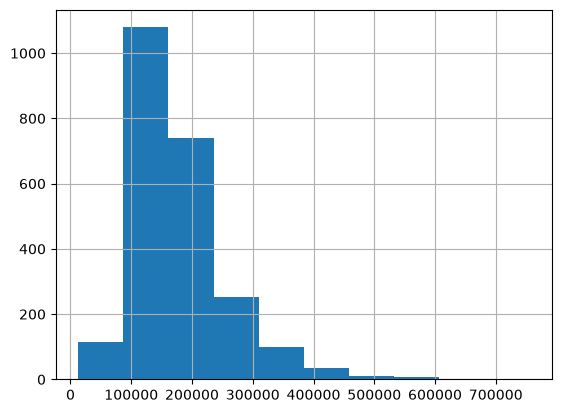

In [42]:

y_train.hist()
print("Skew =", y_train.skew())
%matplotlib inline

**Observation :** distribution fortement asymétrique à droite (skew ≈ 1.75).
La majorité des maisons se situe entre 100k et 200k, avec une longue traîne
de maisons plus chères jusqu'à ~700k. → à prendre en compte pour une
transformation log de `SalePrice` en Phase 3.

## Missing values

In [43]:
missing_pct = X_train.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
missing_pct

Pool QC           99.488055
Misc Feature      95.989761
Alley             93.088737
Fence             79.948805
Mas Vnr Type      60.836177
Fireplace Qu      48.805461
Lot Frontage      16.766212
Garage Cond        5.204778
Garage Finish      5.204778
Garage Yr Blt      5.204778
Garage Qual        5.204778
Garage Type        5.119454
Bsmt Exposure      2.687713
BsmtFin Type 2     2.645051
Bsmt Qual          2.602389
Bsmt Cond          2.602389
BsmtFin Type 1     2.602389
Mas Vnr Area       0.810580
Bsmt Full Bath     0.042662
Garage Area        0.042662
Total Bsmt SF      0.042662
Bsmt Unf SF        0.042662
BsmtFin SF 2       0.042662
Bsmt Half Bath     0.042662
Garage Cars        0.042662
BsmtFin SF 1       0.042662
dtype: float64

**Observations :**

- `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Mas Vnr Type`, `Fireplace Qu`
  (48% à 99% manquant) — structurel : l'élément n'existe pas sur la maison
  → catégorie dédiée "None" (pas d'imputation par mode)
- `Lot Frontage` (16.8% manquant) — ambigu : toute maison a une façade,
  donc vraie non-collecte → imputation par médiane
- `Garage Yr Blt`, `Garage Cond`, `Garage Finish`, `Garage Qual`, `Garage Type`
  (≈5.2% manquant) — structurel : pas de garage → catégorie "None"
  (catégorielles) / 0 ou indicateur (numérique pour `Garage Yr Blt`)
- `Bsmt Exposure`, `BsmtFin Type 2`, `BsmtFin Type 1`, `Bsmt Qual`, `Bsmt Cond`
  (≈2.6% manquant), + `Mas Vnr Area`, `Bsmt Full Bath`, `Total Bsmt SF`,
  `Garage Area`, `Garage Cars`, `Bsmt Unf SF`, `BsmtFin SF 2`, `Bsmt Half Bath`,
  `BsmtFin SF 1` (≤0.81% manquant) — structurel : pas de sous-sol / pas de
  revêtement maçonnerie → 0 (numérique) ou "None" (catégorielle)

→ Seule `Lot Frontage` nécessite une imputation "classique" (médiane).
Tout le reste est un manquant structurel à coder explicitement.

## Numeric feature distributions

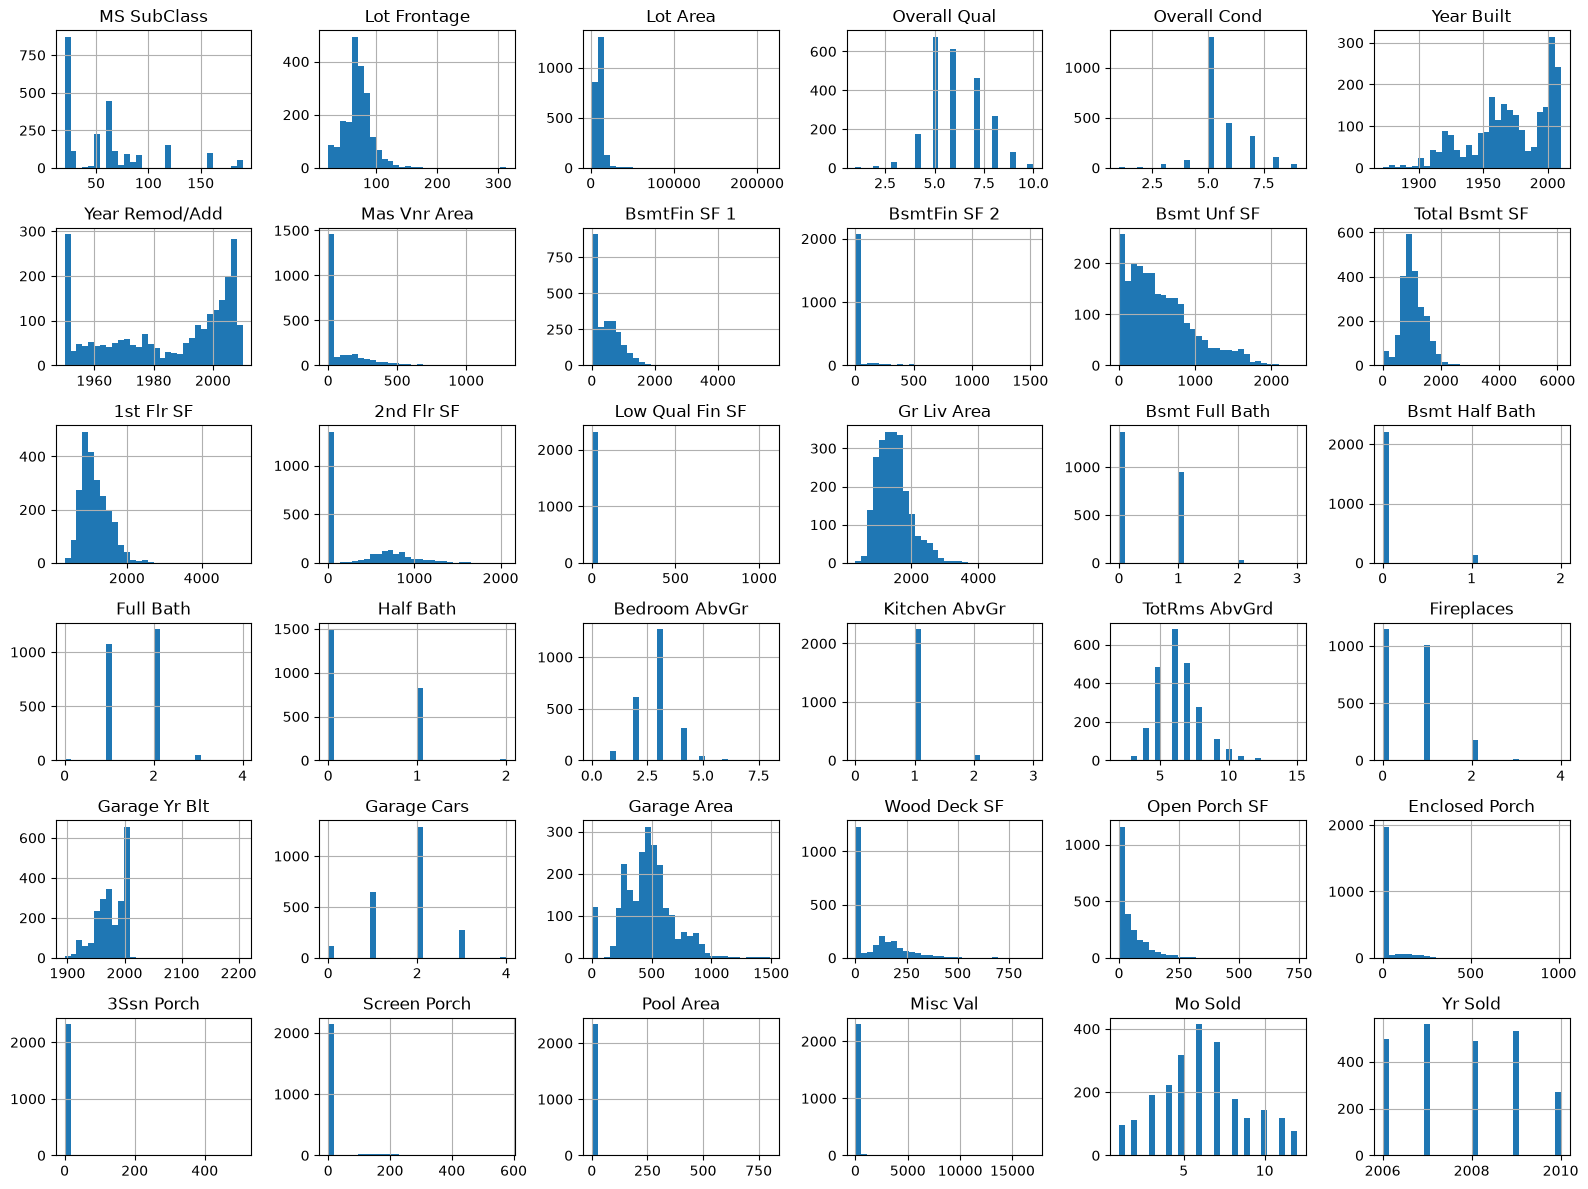

In [44]:
numeric_cols = X_train.select_dtypes(include='number').columns
X_train[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()


**Observations :**

- Outliers isolés forts : `Lot Area`, `Mas Vnr Area`, `BsmtFin SF 1/2`,
  `Total Bsmt SF`, `Garage Area` → à surveiller (capping ou vigilance
  selon impact sur le modèle en Phase 3)
- Majoritairement à zéro, peu de variance : `Low Qual Fin SF`,
  `Bsmt Half Bath`, `3Ssn Porch`, `Screen Porch`, `Pool Area`, `Misc Val`,
  `Enclosed Porch` → candidates à exclure ou regrouper
- `Garage Yr Blt` — axe anormalement étendu (~2200), à vérifier précisément
  ci-dessous
- `Year Built`/`Garage Yr Blt` bimodales (vagues de construction anciennes
  vs récentes) — observation, pas un problème de qualité

In [45]:
print("Typo in data:", (X_train['Garage Yr Blt'] > 2100).any())
print("Typo value:", X_train.loc[X_train['Garage Yr Blt'] > 2100, 'Garage Yr Blt'])

Typo in data: True
Typo value: 2260    2207.0
Name: Garage Yr Blt, dtype: float64


**Observation :** `Garage Yr Blt` contient une valeur aberrante à l'index
2260 (2207.0), probable inversion de chiffres (2007 → 2207).
→ Corrigée dans `preprocessing.py` par `fix_known_data_errors`,
exécutée avant `add_structural_indicators`/`fill_structural_na`.

## Categorical feature distributions

In [46]:
categorical_cols = X_train.select_dtypes(include='object').columns

for col in categorical_cols:
    top_freq = X_train[col].value_counts(normalize=True).iloc[0]
    n_categories = X_train[col].nunique()
    if top_freq > 0.9 or n_categories > 10:
        print(f"--- {col} (top category: {top_freq:.0%}, {n_categories} categories) ---")
        print(X_train[col].value_counts())
        print()

--- Street (top category: 100%, 2 categories) ---
Street
Pave    2333
Grvl      11
Name: count, dtype: int64

--- Utilities (top category: 100%, 3 categories) ---
Utilities
AllPub    2341
NoSewr       2
NoSeWa       1
Name: count, dtype: int64

--- Land Slope (top category: 95%, 3 categories) ---
Land Slope
Gtl    2228
Mod     102
Sev      14
Name: count, dtype: int64

--- Neighborhood (top category: 16%, 28 categories) ---
Neighborhood
NAmes      367
CollgCr    211
OldTown    199
Edwards    150
Gilbert    138
Somerst    136
NridgHt    121
Sawyer     119
NWAmes     109
SawyerW     98
Mitchel     97
Crawfor     89
BrkSide     84
IDOTRR      73
Timber      59
NoRidge     57
SWISU       37
StoneBr     36
ClearCr     35
MeadowV     28
BrDale      24
Blmngtn     23
Veenker     22
NPkVill     15
Blueste      7
Greens       7
GrnHill      2
Landmrk      1
Name: count, dtype: int64

--- Condition 2 (top category: 99%, 8 categories) ---
Condition 2
Norm      2324
Feedr       10
Artery       3
P

C:\Users\balia\AppData\Local\Temp\ipykernel_9512\392291686.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include='object').columns


**Observations (colonnes catégorielles à catégorie dominante >90% ou >10 catégories) :**

- Quasi-constantes (>95%, très peu de signal) — `Street`, `Utilities`,
  `Condition 2`, `Roof Matl`, `Heating`, `Garage Cond`, `Land Slope`
  → candidates à exclure du modèle
- Dominance forte mais modérée (90-94%) — `Central Air`, `Functional`,
  `Garage Qual`, `Electrical`, `Bsmt Cond`, `Paved Drive` → à surveiller,
  pas à exclure d'office
- Haute cardinalité, répartition saine — `Neighborhood` (28 catégories),
  `Exterior 1st`/`Exterior 2nd` (16 catégories chacune, quasi-redondantes
  entre elles) → à garder en tête pour la taille du one-hot encoding
- `Garage Cond`/`Garage Qual` recoupent le manquant structurel déjà
  identifié au Bloc 3 (pas de garage) → traitement combiné à prévoir

## Feature vs target relationships

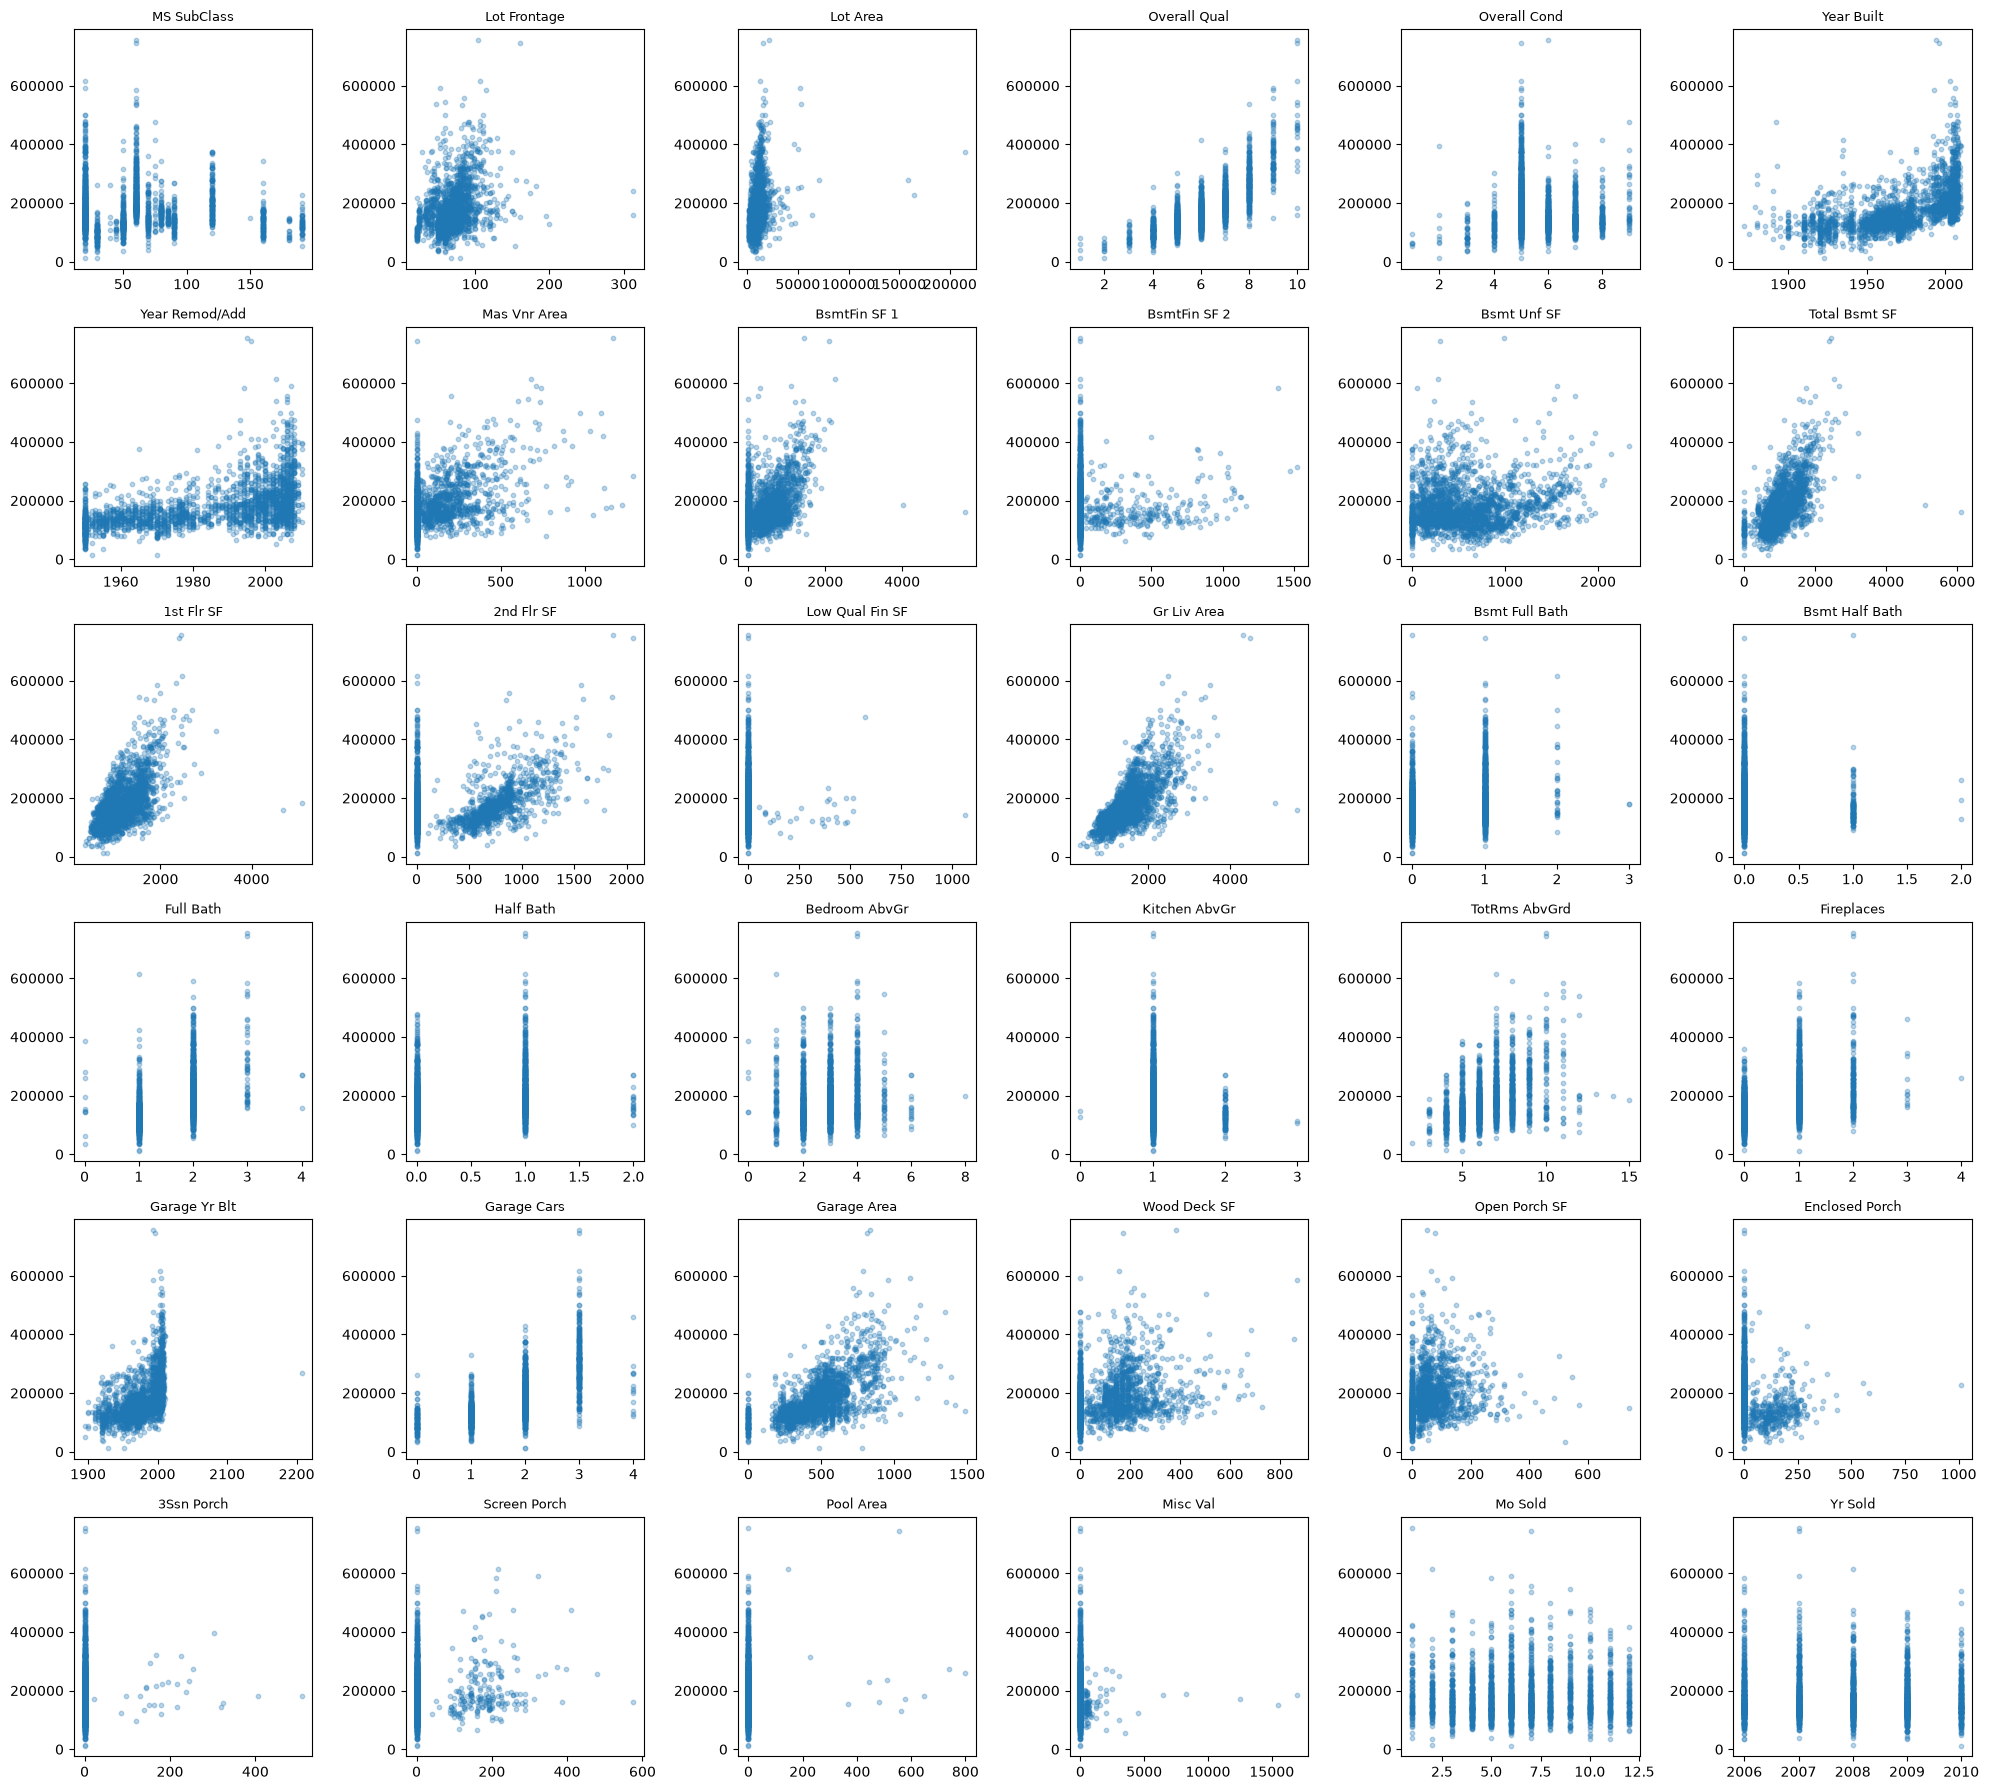

In [47]:
numeric_cols = X_train.select_dtypes(include='number').columns
n_cols = 6
n_rows = -(-len(numeric_cols) // n_cols)  # arrondi vers le haut

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(X_train[col], y_train, alpha=0.3, s=10)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

**Observations :**

- Relations fortes et claires avec `SalePrice` : `Overall Qual`, `Gr Liv Area`,
  `Total Bsmt SF`, `1st Flr SF`, `Garage Cars`, `Garage Area`, `Year Built`,
  `Garage Yr Blt` → candidates fortes pour la feature importance
- Relations présentes mais plus dispersées : `Mas Vnr Area`, `BsmtFin SF 1`,
  `2nd Flr SF`, `TotRms AbvGrd`, `Full Bath`, `Fireplaces`
- Peu ou pas de relation visible : `Mo Sold`, `Yr Sold`, `Misc Val`,
  `Pool Area`, `3Ssn Porch`, `BsmtFin SF 2`, `Low Qual Fin SF`,
  `Overall Cond` (contraste notable avec `Overall Qual`, qui elle est
  clairement informative)
- `Garage Yr Blt` : point aberrant (~2260) toujours visible ici, confirmé
  isolé du nuage principal — cohérent avec la correction déjà prévue

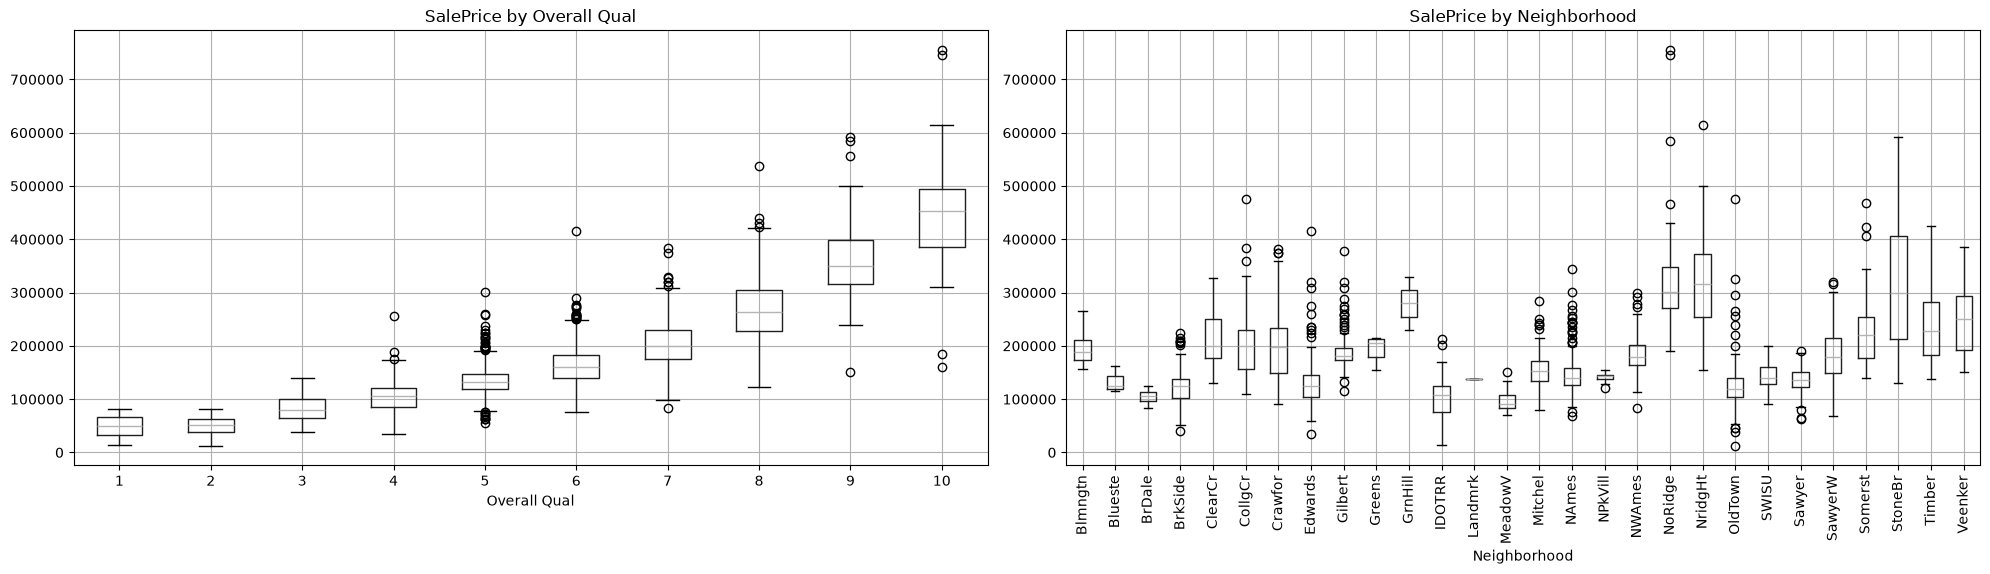

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

X_train.assign(SalePrice=y_train).boxplot(column='SalePrice', by='Overall Qual', ax=axes[0])
axes[0].set_title('SalePrice by Overall Qual')

X_train.assign(SalePrice=y_train).boxplot(column='SalePrice', by='Neighborhood', ax=axes[1], rot=90)
axes[1].set_title('SalePrice by Neighborhood')

plt.suptitle('')
plt.tight_layout()

**Observations :**

- `Overall Qual` — relation quasi monotone parfaite avec `SalePrice`,
  la médiane augmente à chaque palier de qualité sans exception →
  probablement la feature la plus prédictive du dataset
- `Neighborhood` — effet clair mais groupé plutôt que linéaire : quartiers
  premium (`NoRidge`, `NridgHt`, `StoneBr`) nettement au-dessus, quartiers
  bas de gamme (`BrDale`, `MeadowV`, `IDOTRR`, `OldTown`) nettement en
  dessous, large groupe intermédiaire entre les deux → variable catégorielle
  clé, encodage à soigner (one-hot avec 28 catégories, ou regroupement en
  Phase 3 selon niveau de prix si besoin de réduire la dimensionnalité)

## Correlations between numeric features

[ 20  60  90 190  80  30 160 120 180  50  70  45  85 150  75  40]


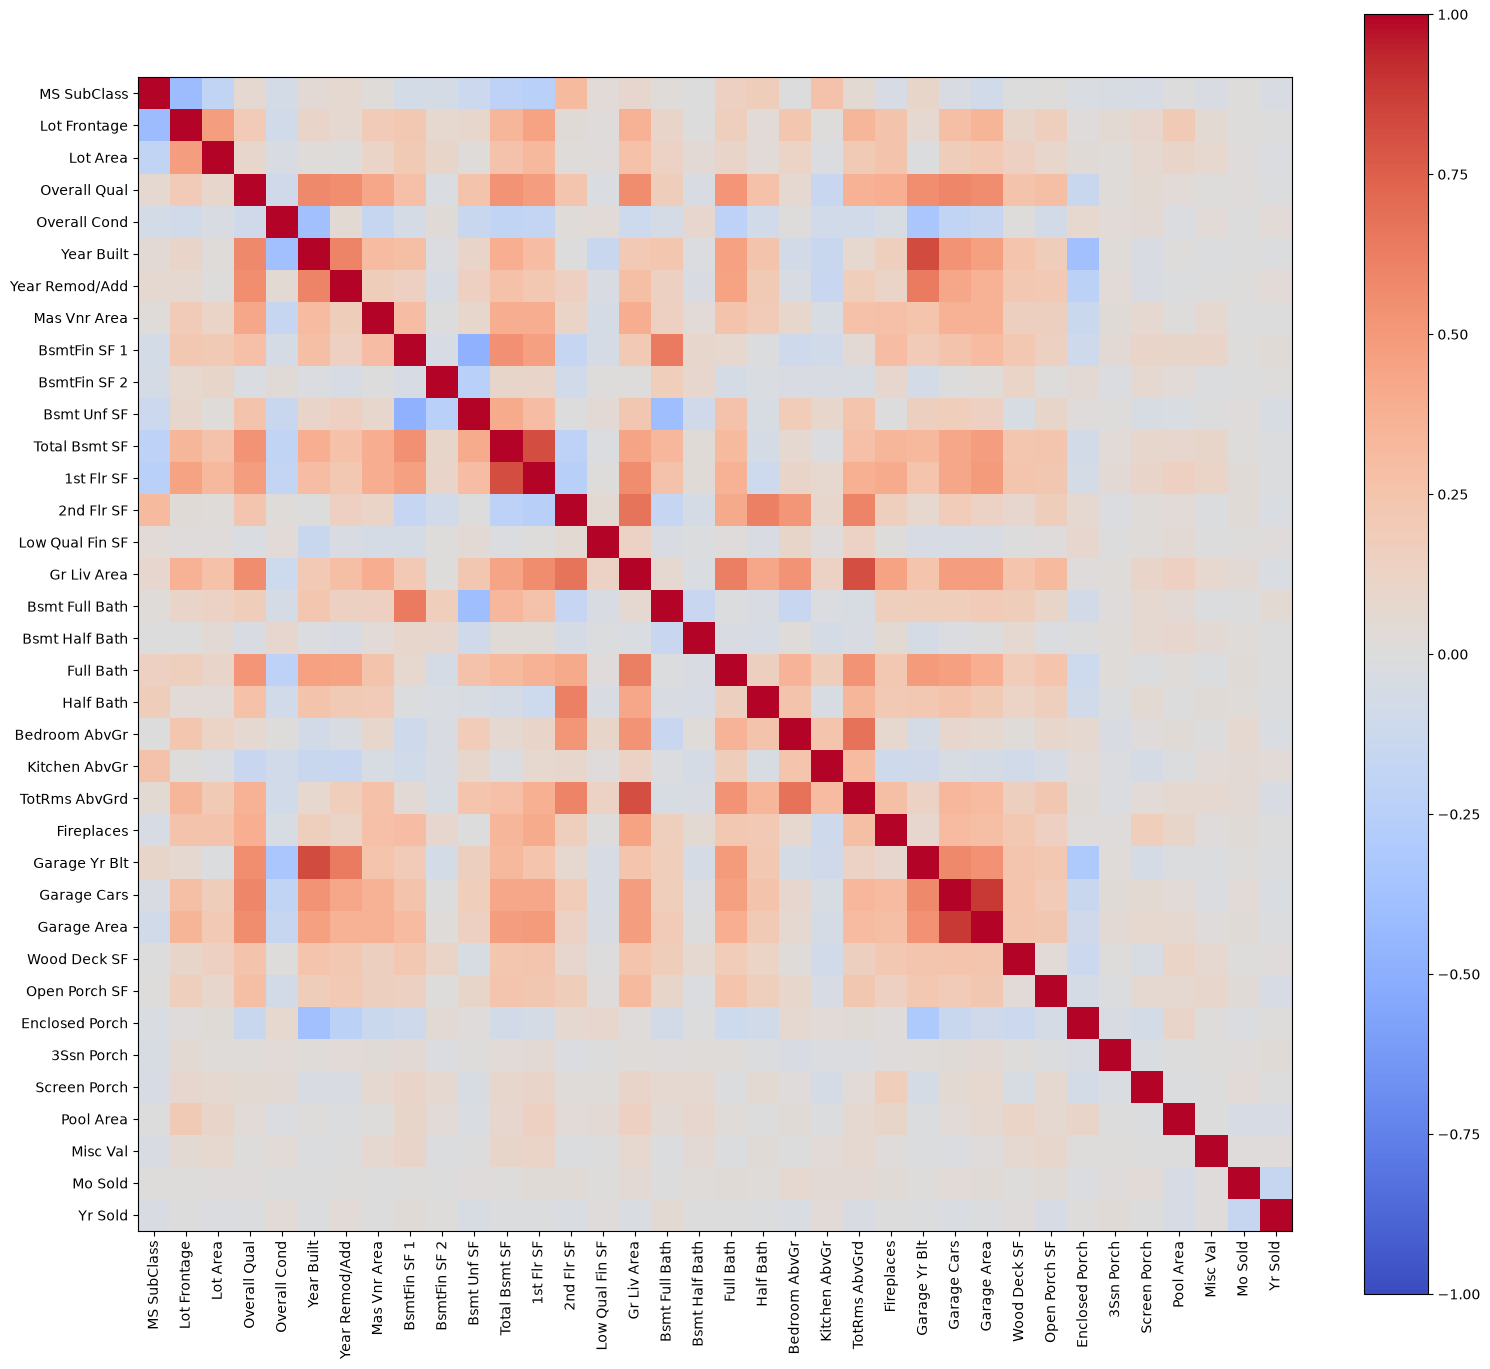

In [49]:
corr_matrix = X_train[numeric_cols].corr()

plt.figure(figsize=(16, 14))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.tight_layout()
print(X_train['MS SubClass'].unique())

**Observations :**

- Paires très fortement corrélées (>0.8) : `Garage Cars`/`Garage Area`,
  `Total Bsmt SF`/`1st Flr SF`, `Year Built`/`Garage Yr Blt`,
  `Gr Liv Area`/`TotRms AbvGrd` → à garder en tête pour l'interprétation
  de la feature importance en Phase 3 (fragmentation pour les arbres,
  répartition pour Ridge), pas forcément à retirer
- `Overall Qual` modérément corrélée avec plusieurs features de taille/âge
  (`Year Built`, `Gr Liv Area`, `Garage Cars`) — cohérent, une maison de
  meilleure qualité tend à être plus grande et plus récente
- `MS SubClass` négativement corrélée avec plusieurs colonnes — à vérifier :
  probablement une variable catégorielle encodée numériquement (type de
  logement), pas une vraie quantité continue → à reclasser en catégorielle
  en Phase 3 si confirmé

## Summary — Preprocessing decisions

### Target (`SalePrice`)
- Skew ≈ 1.75 (strong right asymmetry) → log transformation to consider
  for linear models in Phase 3

### Corrections to apply before any NaN/encoding handling
- `Garage Yr Blt`, index 2260: 2207.0 → 2007.0 (digit inversion typo)
  → `fix_known_data_errors`, must run before `add_structural_indicators`
  and `fill_structural_na`
- `Unnamed: 0` (index artifact from CSV read) → already fixed at load time
  (`index_col=0` in `load_raw_data`), not a feature to handle here

### Structural missing values (→ "None" category / 0 + presence indicator)
- `Pool QC`, `Misc Feature`, `Alley`, `Fence`, `Mas Vnr Type`, `Fireplace Qu`
  (48–99% missing)
- `Garage Yr Blt`, `Garage Cond`, `Garage Finish`, `Garage Qual`, `Garage Type`
  (≈5.2% missing)
- `Bsmt Exposure`, `BsmtFin Type 1/2`, `Bsmt Qual`, `Bsmt Cond`,
  `Mas Vnr Area`, `Bsmt Full/Half Bath`, `Total Bsmt SF`, `Garage Area`,
  `Garage Cars`, `Bsmt Unf SF`, `BsmtFin SF 1/2` (≤2.7% missing)

### Ambiguous missing values (→ standard imputation)
- `Lot Frontage` (16.8% missing) → median imputation

### Numeric columns to watch (outliers, possible capping)
- `Lot Area`, `Mas Vnr Area`, `BsmtFin SF 1/2`, `Total Bsmt SF`,
  `Garage Area` — isolated extreme values, decision deferred to
  model impact assessment in Phase 3

### Categorical columns — near-constant (candidates to exclude)
- `Street`, `Utilities`, `Condition 2`, `Roof Matl`, `Heating`,
  `Garage Cond`, `Land Slope` (>95% dominant category)

### Categorical columns — moderate dominance (to watch, not exclude)
- `Central Air`, `Functional`, `Garage Qual`, `Electrical`, `Bsmt Cond`,
  `Paved Drive` (90–94%)

### Numeric → categorical reclassification
- `MS SubClass` — confirmed nominal (dwelling type codes, De Cock 2011 doc),
  not a true continuous variable → exclude from numeric dtype selection,
  encode as categorical (one-hot)

### Strongly correlated feature pairs (keep in mind, not to drop by default)
- `Garage Cars` / `Garage Area`
- `Total Bsmt SF` / `1st Flr SF`
- `Year Built` / `Garage Yr Blt`
- `Gr Liv Area` / `TotRms AbvGrd`
- `Exterior 1st` / `Exterior 2nd` (high cardinality, likely redundant)

### Most promising predictive features (for later comparison with model
feature importance)
- `Overall Qual` (near-perfect monotonic relationship with `SalePrice`)
- `Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`, `Garage Cars`, `Garage Area`,
  `Year Built`
- `Neighborhood` (grouped effect: premium vs low-tier neighborhoods clearly
  separated)